# Image Captioning ” Fast From-Scratch CNN Encoder + Cross-Attention Decoder (PyTorch) All model weights are trained from scratch. The data are split by unique image: 500 validation images choose the best epoch, 500 separate test images are used only for final metrics, and all remaining images are used for training.

In [1]:
# ============================================
# Step 1: Import the libraries needed for the project
# ============================================
import os
import re
import math
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


# ============================================
# Step 2: Set a fixed random seed
# This makes random operations reproducible
# so we can get similar results every time.
# ============================================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================
# Step 3: Select the device for training
# Use GPU if CUDA is available, otherwise use CPU.
# ============================================
DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)


# ============================================
# Step 4: Define the image size
# 192x192 is used to reduce GPU memory usage
# and make training from scratch easier on a T4 GPU.
# ============================================
IMAGE_SIZE = 192


# ============================================
# Step 5: Define the batch size
# 64 images will be processed together in each
# training iteration.
# ============================================
BATCH_SIZE = 64


# ============================================
# Step 6: Define the number of DataLoader workers
# Multiple workers load and preprocess images
# in parallel to speed up data loading.
# ============================================
NUM_WORKERS = 4


# ============================================
# Step 7: Define the maximum number of training epochs
# The model can train for up to 15 complete passes
# over the training dataset.
# ============================================
EPOCHS = 15


# ============================================
# Step 8: Define Early Stopping patience
# If validation performance does not improve for
# 3 consecutive epochs, training can be stopped.
# ============================================
PATIENCE = 3


# ============================================
# Step 9: Set the learning rate
# This controls how much the model weights change
# after each optimization step.
# ============================================
LEARNING_RATE = 5e-4


# ============================================
# Step 10: Set the maximum vocabulary size
# The vocabulary will contain at most 12,000 words.
# ============================================
MAX_VOCAB_SIZE = 12000


# ============================================
# Step 11: Set the minimum word frequency
# Words that appear fewer than 2 times can be
# excluded from the vocabulary.
# ============================================
MIN_WORD_FREQUENCY = 2


# ============================================
# Step 12: Define the number of validation images
# Exactly 500 unique images will be reserved
# for validation.
# ============================================
VALIDATION_IMAGES = 500


# ============================================
# Step 13: Define the number of test images
# Exactly 500 unique images will be reserved
# for final testing.
# ============================================
TEST_IMAGES = 500


# ============================================
# Step 14: Initialize the caption file paths
# None means the code will automatically search
# for the correct files later.
# ============================================
TRAIN_CAPTIONS_FILE = None
VALIDATION_CAPTIONS_FILE = None


# ============================================
# Step 15: Initialize the images directory
# None means the code will automatically determine
# the images location later.
# ============================================
IMAGES_DIR = None


# ============================================
# Step 16: Display which device will be used
# ============================================
print('Device:', DEVICE)


# ============================================
# Step 17: If a GPU is available, display its name
# This helps us verify which NVIDIA GPU PyTorch
# is actually using.
# ============================================
if DEVICE.type == 'cuda':
    print(torch.cuda.get_device_name(0))

Device: cuda
Tesla T4


In [2]:
# ============================================
# Step 1: Define the root directory of the dataset
# Kaggle stores the attached datasets inside /kaggle/input
# ============================================
INPUT_ROOT = Path('/kaggle/input')


# ============================================
# Step 2: Define the image file extensions
# These are the image formats that the code will search for
# ============================================
IMAGE_EXTENSIONS = {
    '.jpg',
    '.jpeg',
    '.png',
    '.bmp',
    '.webp'
}


# ============================================
# Step 3: Find all files inside /kaggle/input
# rglob('*') searches recursively inside all subfolders
# ============================================
all_files = [
    path
    for path in INPUT_ROOT.rglob('*')
    if path.is_file()
]


# ============================================
# Step 4: Keep only image files
# Check the extension of every file against IMAGE_EXTENSIONS
# ============================================
image_files = [
    path
    for path in all_files
    if path.suffix.lower() in IMAGE_EXTENSIONS
]


# ============================================
# Step 5: Find possible annotation/caption files
# The code considers CSV, TSV, and TXT files
# ============================================
text_files = [
    path
    for path in all_files
    if path.suffix.lower() in {'.csv', '.tsv', '.txt'}
]


# ============================================
# Step 6: Identify files that are likely to contain captions
# The filename must contain one of these keywords:
# caption, token, text, or description
# ============================================
caption_candidates = [
    p
    for p in text_files
    if any(
        key in p.name.lower()
        for key in ('caption', 'token', 'text', 'description')
    )
]


# ============================================
# Step 7: Automatically locate the training captions file
# If TRAIN_CAPTIONS_FILE was not manually specified,
# search for a caption file whose name contains "train"
# ============================================
if TRAIN_CAPTIONS_FILE is None:
    TRAIN_CAPTIONS_FILE = next(
        (
            p
            for p in caption_candidates
            if 'train' in p.name.lower()
        ),
        None
    )


# ============================================
# Step 8: Automatically locate the validation/extra captions file
# Search for a caption file containing:
# val, valid, or dev
# ============================================
if VALIDATION_CAPTIONS_FILE is None:
    VALIDATION_CAPTIONS_FILE = next(
        (
            p
            for p in caption_candidates
            if any(
                key in p.name.lower()
                for key in ('val', 'valid', 'dev')
            )
        ),
        None
    )


# ============================================
# Step 9: Make sure both caption files were found
# If either file is missing, stop the program and
# ask the user to specify the paths manually
# ============================================
if TRAIN_CAPTIONS_FILE is None or VALIDATION_CAPTIONS_FILE is None:
    raise FileNotFoundError(
        'Could not find both caption files. Set their paths manually.'
    )


# ============================================
# Step 10: Automatically determine the images directory
# Find the common parent directory shared by the image files
# ============================================
if IMAGES_DIR is None:
    IMAGES_DIR = Path(
        os.path.commonpath(
            [
                str(path.parent)
                for path in image_files
            ]
        )
    )


# ============================================
# Step 11: Print the number of images found
# The comma formatting makes large numbers easier to read
# ============================================
print(f'Images: {len(image_files):,}')


# ============================================
# Step 12: Display the training captions file path
# ============================================
print('Train captions:', TRAIN_CAPTIONS_FILE)


# ============================================
# Step 13: Display the extra captions file path
# This file will later be pooled with the training captions
# before creating the validation/test split
# ============================================
print('Extra captions to pool:', VALIDATION_CAPTIONS_FILE)

Images: 64,143
Train captions: /kaggle/input/datasets/amjadbakri/captioning-dataset/train_captioning.csv
Extra captions to pool: /kaggle/input/datasets/amjadbakri/captioning-dataset/val_captioning.csv


In [3]:
# ============================================
# Step 1: Load a caption/annotation file
# This function reads the file and tries to identify
# the image-name column and the caption/text column.
# ============================================
def load_caption_table(path):

    # Read the file using Pandas.
    # sep=None allows Pandas to automatically detect
    # the separator such as comma, tab, etc.
    # Bad/malformed lines are skipped instead of stopping execution.
    table = pd.read_csv(
        path,
        sep=None,
        engine='python',
        on_bad_lines='skip'
    )

    # Create a mapping between normalized column names
    # and their original names.
    # Example: " Image_Name " -> "image_name"
    columns = {
        str(column).strip().lower(): column
        for column in table.columns
    }

    # ============================================
    # Step 1.1: Find the image column
    # Look for common names that may represent the image filename.
    # ============================================
    image_column = next(
        (
            columns[key]
            for key in columns
            if key in {
                'image',
                'image_name',
                'filename',
                'file_name',
                'img'
            }
        ),
        None
    )

    # ============================================
    # Step 1.2: Find the caption column
    # Look for common names that may contain the image caption.
    # ============================================
    caption_column = next(
        (
            columns[key]
            for key in columns
            if key in {
                'caption',
                'comment',
                'description',
                'text',
                'sentence'
            }
        ),
        None
    )

    # ============================================
    # Step 1.3: If both columns were found,
    # keep only those two columns and rename them
    # to a standard format.
    # ============================================
    if image_column is not None and caption_column is not None:
        return table[
            [image_column, caption_column]
        ].rename(
            columns={
                image_column: 'image_name',
                caption_column: 'caption'
            }
        )

    # ============================================
    # Step 1.4: If the columns could not be identified,
    # try to manually parse the file line by line.
    # ============================================
    pairs = []

    for line in Path(path).read_text(
        encoding='utf-8',
        errors='ignore'
    ).splitlines():

        # Try different separators:
        # - Tab
        # - |
        # - Comma
        # maxsplit=1 ensures we split only between
        # the image name and the caption.
        parts = re.split(
            r'\t|\s*\|\s*|,(?=\s*[A-Za-z])',
            line,
            maxsplit=1
        )

        # ============================================
        # Step 1.5: Check that the line contains exactly
        # an image name and a caption.
        # Also verify that the first part has a valid
        # image extension.
        # ============================================
        if (
            len(parts) == 2
            and Path(
                parts[0].split('#')[0].strip()
            ).suffix.lower() in IMAGE_EXTENSIONS
        ):

            # Store the image name and its caption.
            # split('#') handles formats such as image.jpg#0.
            pairs.append(
                (
                    Path(
                        parts[0].split('#')[0].strip()
                    ).name,
                    parts[1].strip()
                )
            )

    # ============================================
    # Step 1.6: Make sure that at least one valid
    # image-caption pair was found.
    # ============================================
    if not pairs:
        raise ValueError(
            f'Could not identify image/caption columns in {path}.'
        )

    # ============================================
    # Step 1.7: Convert the extracted pairs into
    # a standardized DataFrame.
    # ============================================
    return pd.DataFrame(
        pairs,
        columns=['image_name', 'caption']
    )


# ============================================
# Step 2: Normalize/clean the captions
# Convert text to lowercase, remove unwanted characters,
# and remove extra spaces.
# ============================================
def normalize_caption(text):

    # Convert the text to lowercase and remove characters
    # other than letters, numbers, apostrophes, and spaces.
    text = re.sub(
        r"[^a-z0-9' ]",
        ' ',
        str(text).lower()
    )

    # Replace multiple spaces with a single space
    # and remove spaces from the beginning/end.
    return re.sub(
        r'\s+',
        ' ',
        text
    ).strip()


# ============================================
# Step 3: Create a dictionary that maps each image filename
# to its actual path on the Kaggle filesystem.
#
# Example:
# "dog.jpg" -> "/kaggle/input/dataset/images/dog.jpg"
# ============================================
path_by_name = {
    path.name: path
    for path in image_files
}


# ============================================
# Step 4: Prepare one caption table
# This function reads, cleans, and connects the captions
# to their actual image files.
# ============================================
def prepare_caption_table(path):

    # Load the caption file, remove rows containing
    # missing values, and create a copy.
    table = load_caption_table(path).dropna().copy()

    # ============================================
    # Step 4.1: Keep only the filename
    # This removes any directory information from the image name.
    # ============================================
    table['image_name'] = table['image_name'].map(
        lambda name: Path(str(name)).name
    )

    # ============================================
    # Step 4.2: Normalize every caption
    # ============================================
    table['caption'] = table['caption'].map(
        normalize_caption
    )

    # ============================================
    # Step 4.3: Match every image filename with its
    # actual path on disk.
    # ============================================
    table['image_path'] = table['image_name'].map(
        path_by_name
    )

    # ============================================
    # Step 4.4: Remove records whose image does not
    # actually exist in the dataset.
    # ============================================
    table = table.dropna(
        subset=['image_path']
    )

    # ============================================
    # Step 4.5: Remove captions that became empty
    # after normalization.
    # ============================================
    return table[
        table.caption.str.len() > 0
    ].reset_index(drop=True)


# ============================================
# Step 5: Load BOTH caption files and combine them
# into one large DataFrame.
#
# Training captions + validation/extra captions
#                  ↓
#             all_captions
# ============================================
all_captions = pd.concat(
    [
        prepare_caption_table(TRAIN_CAPTIONS_FILE),
        prepare_caption_table(VALIDATION_CAPTIONS_FILE)
    ],
    ignore_index=True
)


# ============================================
# Step 6: Remove duplicate image-caption pairs
# If exactly the same image has exactly the same caption
# more than once, keep only one copy.
# ============================================
all_captions = all_captions.drop_duplicates(
    ['image_name', 'caption']
).reset_index(drop=True)


# ============================================
# Step 7: Extract all unique image names
# We need unique images because the train/validation/test
# split must happen at the IMAGE level, not caption level.
# ============================================
image_names = np.array(
    sorted(
        all_captions.image_name.unique()
    )
)


# ============================================
# Step 8: Make sure the dataset contains enough images
# to reserve both validation and test sets while still
# leaving images for training.
# ============================================
if len(image_names) <= VALIDATION_IMAGES + TEST_IMAGES:
    raise ValueError(
        'There must be more images than validation plus test images.'
    )


# ============================================
# Step 9: Create a reproducible random generator
# SEED ensures that the same images are selected
# every time the code is run with the same seed.
# ============================================
rng = np.random.default_rng(SEED)


# ============================================
# Step 10: Randomly select the images that will be
# removed from training and reserved for validation/test.
#
# replace=False means the same image cannot be selected twice.
# ============================================
held_out_names = rng.choice(
    image_names,
    size=VALIDATION_IMAGES + TEST_IMAGES,
    replace=False
)


# ============================================
# Step 11: Select the validation images
# The first VALIDATION_IMAGES from the selected images
# will become the validation set.
# ============================================
validation_names = set(
    held_out_names[:VALIDATION_IMAGES]
)


# ============================================
# Step 12: Select the test images
# The remaining selected images will become the test set.
# ============================================
test_names = set(
    held_out_names[VALIDATION_IMAGES:]
)


# ============================================
# Step 13: Build the validation DataFrame
# Keep ALL captions belonging to the selected validation images.
# ============================================
validation_table = all_captions[
    all_captions.image_name.isin(validation_names)
].reset_index(drop=True)


# ============================================
# Step 14: Build the test DataFrame
# Keep ALL captions belonging to the selected test images.
# ============================================
test_table = all_captions[
    all_captions.image_name.isin(test_names)
].reset_index(drop=True)


# ============================================
# Step 15: Build the training DataFrame
# Keep every image that is NOT part of validation or test.
# ============================================
captions = all_captions[
    ~all_captions.image_name.isin(
        validation_names | test_names
    )
].reset_index(drop=True)


# ============================================
# Step 16: Get the unique training image names
# ============================================
train_names = set(
    captions.image_name
)


# ============================================
# Step 17: Verify that no training image appears
# in the validation set.
# ============================================
assert train_names.isdisjoint(
    validation_names
)


# ============================================
# Step 18: Verify that no training image appears
# in the test set.
# ============================================
assert train_names.isdisjoint(
    test_names
)


# ============================================
# Step 19: Verify that no validation image appears
# in the test set.
# ============================================
assert validation_names.isdisjoint(
    test_names
)


# ============================================
# Step 20: Verify that every image belongs to exactly
# one of the three sets:
# Train + Validation + Test
# ============================================
assert (
    len(train_names)
    + len(validation_names)
    + len(test_names)
    == len(image_names)
)


# ============================================
# Step 21: Display the first few training records
# to verify that the resulting DataFrame looks correct.
# ============================================
display(
    captions.head()
)


# ============================================
# Step 22: Display training statistics
# "pairs" = number of image-caption records
# "unique images" = number of different images
# ============================================
print(
    f'Train pairs: {len(captions):,}; '
    f'unique images: {len(train_names):,}'
)


# ============================================
# Step 23: Display validation statistics
# ============================================
print(
    f'Validation pairs: {len(validation_table):,}; '
    f'unique images: {len(validation_names):,}'
)


# ============================================
# Step 24: Display test statistics
# ============================================
print(
    f'Test pairs: {len(test_table):,}; '
    f'unique images: {len(test_names):,}'
)

,image_name,caption,image_path
0,000000571635.jpg,a bathroom with a toilet sink and shower,/kaggle/input/datasets/amjadbakri/captioning-d...
1,000000301837.jpg,a long empty minimal modern skylit home kitchen,/kaggle/input/datasets/amjadbakri/captioning-d...
2,000000315702.jpg,a bathroom sink with toiletries on the counter,/kaggle/input/datasets/amjadbakri/captioning-d...
3,000000315702.jpg,a bathroom sink and various personal hygiene i...,/kaggle/input/datasets/amjadbakri/captioning-d...
4,000000189634.jpg,this is an open box containing four cucumbers,/kaggle/input/datasets/amjadbakri/captioning-d...


Train pairs: 315,723; unique images: 63,143
Validation pairs: 2,499; unique images: 500
Test pairs: 2,501; unique images: 500


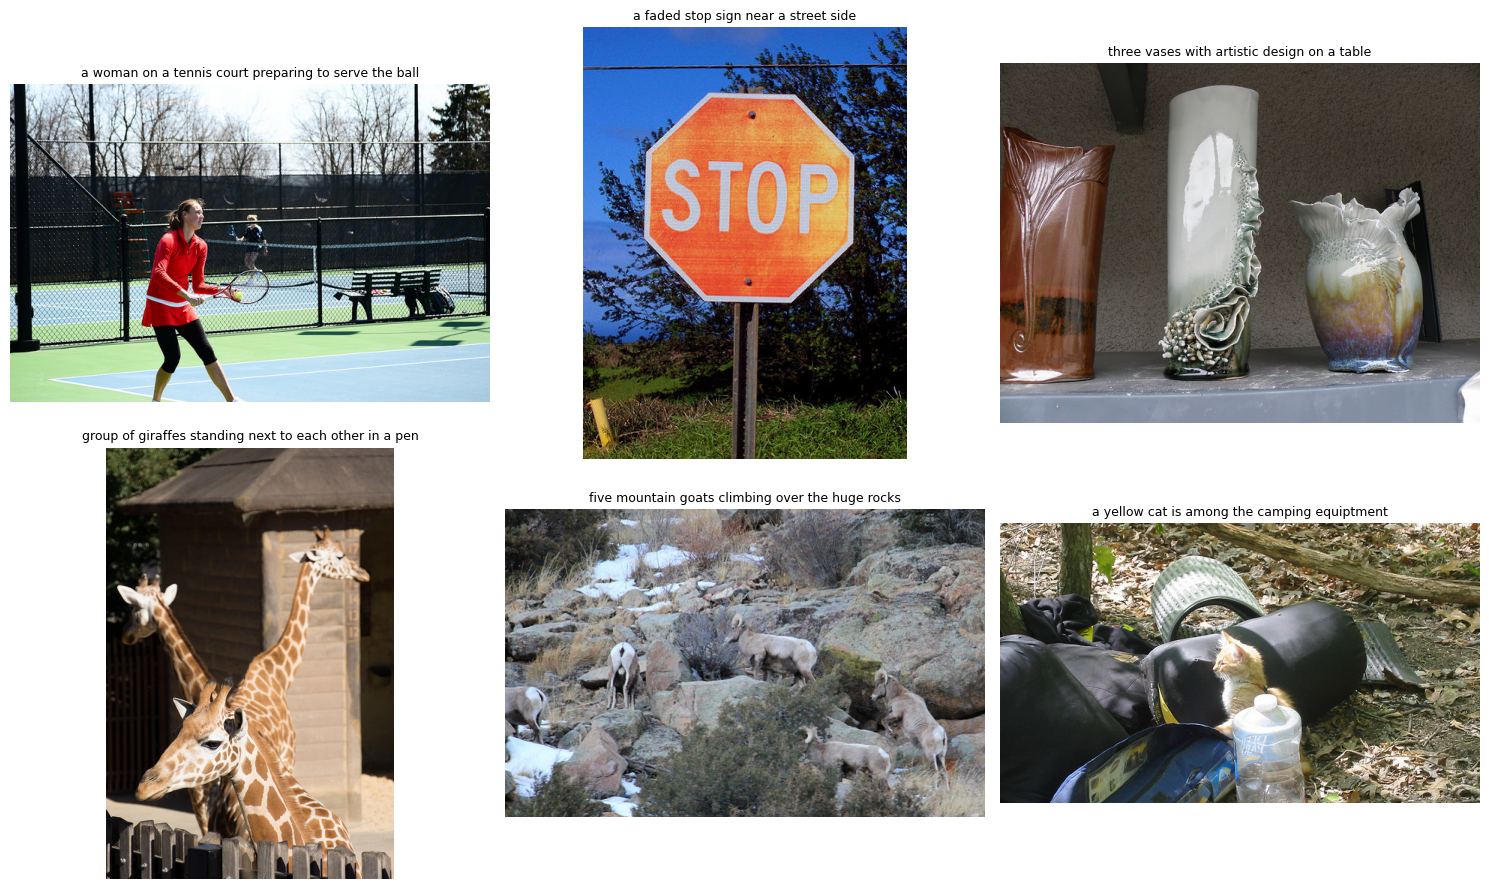

count    315723.000000
mean         10.470121
std           2.400152
min           6.000000
25%           9.000000
50%          10.000000
75%          11.000000
max          50.000000
Name: word_count, dtype: float64
Most common words: [('a', 522325), ('on', 114649), ('of', 109009), ('the', 105510), ('in', 98407), ('with', 82532), ('and', 74844), ('is', 52364), ('man', 38930), ('to', 36463), ('sitting', 28238), ('an', 26593), ('two', 26073), ('at', 23063), ('standing', 22631), ('people', 22091), ('are', 21888), ('next', 19797), ('white', 19447), ('woman', 18018)]


In [4]:
# ============================================
# Step 1: Randomly select a small sample of image-caption pairs
# We select up to 6 samples so we can visually inspect
# whether the images and their captions match correctly.
# random_state=SEED makes the selected samples reproducible.
# ============================================
samples = captions.sample(
    min(6, len(captions)),
    random_state=SEED
)


# ============================================
# Step 2: Create a 2x3 grid for displaying the images
# This gives us space for up to 6 image-caption pairs.
# figsize controls the overall figure size.
# ============================================
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)


# ============================================
# Step 3: Loop through the selected samples
# and display each image with its corresponding caption.
# ============================================
for axis, (_, row) in zip(
    axes.flat,
    samples.iterrows()
):

    # ============================================
    # Step 3.1: Load the image from its actual path
    # and convert it to RGB format.
    # ============================================
    axis.imshow(
        Image.open(
            row.image_path
        ).convert('RGB')
    )

    # ============================================
    # Step 3.2: Display the caption as the image title
    # fontsize controls the text size.
    # wrap=True allows long captions to wrap into
    # multiple lines instead of going outside the figure.
    # ============================================
    axis.set_title(
        row.caption,
        fontsize=9,
        wrap=True
    )

    # ============================================
    # Step 3.3: Hide the x-axis and y-axis
    # because they are not useful for displaying images.
    # ============================================
    axis.axis('off')


# ============================================
# Step 4: Automatically adjust the spacing
# between images and captions.
# ============================================
plt.tight_layout()


# ============================================
# Step 5: Display the final visualization
# ============================================
plt.show()


# ============================================
# Step 6: Calculate the number of words in every caption
# split() separates each caption into individual words,
# and len() counts those words.
#
# Example:
# "a dog running outside" → 4 words
# ============================================
captions['word_count'] = (
    captions.caption
    .str.split()
    .map(len)
)


# ============================================
# Step 7: Display statistical information about
# the caption word counts.
#
# This gives us:
# count, mean, std, min, 25%, 50%, 75%, max
# ============================================
print(
    captions.word_count.describe()
)


# ============================================
# Step 8: Find the 20 most frequently occurring words
# First combine all captions into one large string,
# then split it into individual words,
# and finally count their frequencies.
# ============================================
print(
    'Most common words:',
    Counter(
        ' '.join(captions.caption).split()
    ).most_common(20)
)

Vocabulary size: 12,000; selected MAX_LENGTH: 17


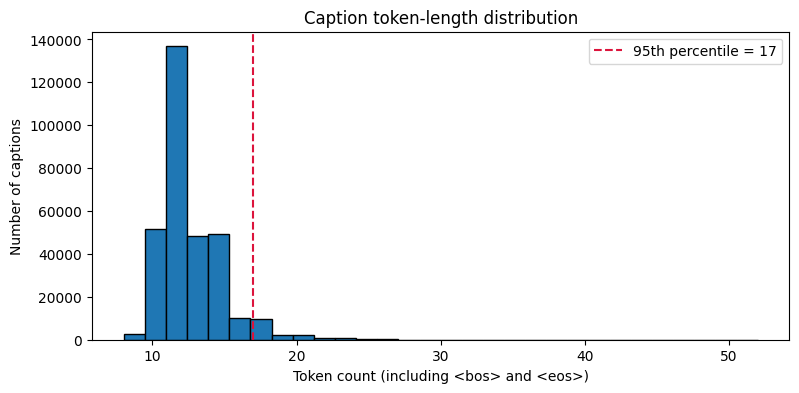

In [5]:
# ============================================
# Step 1: Define the special tokens
# These tokens have special meanings for the model:
#
# <pad> -> used to make captions the same length
# <bos> -> Beginning Of Sentence
# <eos> -> End Of Sentence
# <unk> -> Unknown word
# ============================================
SPECIAL_TOKENS = [
    '<pad>',
    '<bos>',
    '<eos>',
    '<unk>'
]


# ============================================
# Step 2: Count how many times each word appears
# across all training captions.
#
# Example:
# "a dog is running"
# "a dog is sleeping"
#
# Results may look like:
# a       -> 2
# dog     -> 2
# is      -> 2
# running -> 1
# sleeping-> 1
# ============================================
word_counts = Counter(
    word
    for caption in captions.caption
    for word in caption.split()
)


# ============================================
# Step 3: Build the vocabulary
#
# MAX_VOCAB_SIZE determines the maximum number
# of words we want to keep.
#
# We reserve some positions for the special tokens,
# so the actual vocabulary words are limited to:
#
# MAX_VOCAB_SIZE - number of special tokens
#
# MIN_WORD_FREQUENCY removes very rare words.
# ============================================
vocabulary_words = [
    word
    for word, count in word_counts.most_common(
        MAX_VOCAB_SIZE - len(SPECIAL_TOKENS)
    )
    if count >= MIN_WORD_FREQUENCY
]


# ============================================
# Step 4: Create the complete vocabulary
#
# The special tokens come first, followed by
# the normal vocabulary words.
#
# Example:
# index 0 -> <pad>
# index 1 -> <bos>
# index 2 -> <eos>
# index 3 -> <unk>
# index 4 -> a
# index 5 -> dog
# ...
# ============================================
itos = SPECIAL_TOKENS + vocabulary_words


# ============================================
# Step 5: Create a word-to-index dictionary
# stoi = String To Index
#
# This allows us to convert a word into its
# corresponding numerical ID.
#
# Example:
# "dog" -> 5
# ============================================
stoi = {
    word: index
    for index, word in enumerate(itos)
}


# ============================================
# Step 6: Define the IDs of the special tokens
#
# Because SPECIAL_TOKENS was defined in this order:
# <pad>, <bos>, <eos>, <unk>
#
# their IDs will be:
# <pad> -> 0
# <bos> -> 1
# <eos> -> 2
# <unk> -> 3
# ============================================
PAD_ID, BOS_ID, EOS_ID, UNK_ID = range(4)


# ============================================
# Step 7: Create a function to encode a caption
# Convert a text caption into a sequence of token IDs.
#
# Example:
#
# "a dog runs"
#
# becomes something like:
#
# [<bos>, a, dog, runs, <eos>]
#
# and then the words are converted into numbers.
# ============================================
def encode_caption(caption):

    return (
        [BOS_ID]
        + [
            stoi.get(word, UNK_ID)
            for word in caption.split()
        ]
        + [EOS_ID]
    )


# ============================================
# Step 8: Encode all training captions
# Each caption is converted from text into
# a list of integer token IDs.
# ============================================
captions['token_ids'] = captions.caption.map(
    encode_caption
)


# ============================================
# Step 9: Encode all validation captions
# Use the SAME vocabulary created from the training data.
# ============================================
validation_table['token_ids'] = validation_table.caption.map(
    encode_caption
)


# ============================================
# Step 10: Encode all test captions
# Again, use the SAME training vocabulary.
# ============================================
test_table['token_ids'] = test_table.caption.map(
    encode_caption
)


# ============================================
# Step 11: Calculate the length of every training caption
#
# len() counts how many tokens are present,
# including <bos> and <eos>.
# ============================================
lengths = captions.token_ids.map(
    len
)


# ============================================
# Step 12: Calculate the 95th percentile of caption lengths
#
# This means we find a length that covers approximately
# 95% of the training captions.
#
# Using the 95th percentile instead of the maximum
# prevents a few unusually long captions from making
# every caption unnecessarily long.
# ============================================
MAX_LENGTH = int(
    np.ceil(
        np.percentile(
            lengths,
            95
        )
    )
)


# ============================================
# Step 13: Restrict MAX_LENGTH to a reasonable range
#
# Minimum = 8 tokens
# Maximum = 40 tokens
#
# This prevents the sequence length from becoming
# either too short or unnecessarily large.
# ============================================
MAX_LENGTH = max(
    8,
    min(MAX_LENGTH, 40)
)


# ============================================
# Step 14: Display the final vocabulary size
# and the selected maximum caption length.
# ============================================
print(
    f'Vocabulary size: {len(itos):,}; '
    f'selected MAX_LENGTH: {MAX_LENGTH}'
)


# ============================================
# Step 15: Create a histogram showing the distribution
# of caption lengths.
#
# This helps us visually understand how long
# the captions usually are.
# ============================================
plt.figure(
    figsize=(9, 4)
)


# ============================================
# Step 16: Plot the caption-length distribution
#
# Each bar represents how many captions have
# a certain token length.
# ============================================
plt.hist(
    lengths,
    bins=30,
    edgecolor='black'
)


# ============================================
# Step 17: Draw a vertical line at MAX_LENGTH
# This shows where we decided to truncate/pad captions.
# ============================================
plt.axvline(
    MAX_LENGTH,
    color='crimson',
    linestyle='--',
    label=f'95th percentile = {MAX_LENGTH}'
)


# ============================================
# Step 18: Add the x-axis label
# ============================================
plt.xlabel(
    'Token count (including <bos> and <eos>)'
)


# ============================================
# Step 19: Add the y-axis label
# ============================================
plt.ylabel(
    'Number of captions'
)


# ============================================
# Step 20: Add a title to the histogram
# ============================================
plt.title(
    'Caption token-length distribution'
)


# ============================================
# Step 21: Display the legend
# The legend explains the vertical MAX_LENGTH line.
# ============================================
plt.legend()


# ============================================
# Step 22: Display the final histogram
# ============================================
plt.show()

In [6]:
# ============================================
# Step 1: Prepare the Train, Validation, and Test tables
# Reset the DataFrame indexes so each dataset starts
# with a clean index from 0.
#
# Note:
# The test table is prepared here but will NOT be loaded
# into a DataLoader during training.
# ============================================
train_table = captions.reset_index(drop=True)
validation_table = validation_table.reset_index(drop=True)
test_table = test_table.reset_index(drop=True)


# ============================================
# Step 2: Define the image preprocessing pipeline
#
# Every image will go through the same transformations
# before being given to the model.
# ============================================
image_transform = transforms.Compose([

    # Resize every image to the fixed size expected by the model.
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    # Convert the PIL image into a PyTorch Tensor.
    # Pixel values are also converted to the [0, 1] range.
    transforms.ToTensor(),

    # Normalize the RGB channels using the standard
    # ImageNet mean and standard deviation.
    #
    # This is commonly used when working with CNNs
    # trained/pretrained on ImageNet.
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
])


# ============================================
# Step 3: Create the ImageCaptionDataset class
#
# This Dataset connects:
#
# Image → Caption → Token IDs
#
# so that each training sample contains both
# the image tensor and its corresponding caption.
# ============================================
class ImageCaptionDataset(Dataset):

    # ============================================
    # Step 3.1: Initialize the dataset
    # ============================================
    def __init__(
        self,
        table,
        transform,
        max_length
    ):

        # Store the DataFrame.
        # reset_index ensures a clean index.
        self.table = table.reset_index(
            drop=True
        )

        # Store the image transformation pipeline.
        self.transform = transform

        # Store the maximum caption length.
        self.max_length = max_length


    # ============================================
    # Step 3.2: Return the number of samples
    # in the dataset.
    # ============================================
    def __len__(self):
        return len(self.table)


    # ============================================
    # Step 3.3: Load one training sample
    #
    # index identifies which image-caption pair
    # we want to retrieve.
    # ============================================
    def __getitem__(self, index):

        # Get the row corresponding to this sample.
        row = self.table.iloc[index]


        # ============================================
        # Step 3.4: Load and preprocess the image
        #
        # Open the image from its path,
        # convert it to RGB,
        # then apply the transformation pipeline.
        # ============================================
        image_tensor = self.transform(
            Image.open(
                row.image_path
            ).convert('RGB')
        )


        # ============================================
        # Step 3.5: Get the tokenized caption
        # The caption was already converted into token IDs
        # in the previous step.
        # ============================================
        token_ids = row.token_ids


        # ============================================
        # Step 3.6: Handle captions that are too long
        #
        # If the caption exceeds MAX_LENGTH:
        #
        # 1. Keep only the first max_length - 1 tokens
        # 2. Add <eos> at the end
        #
        # This guarantees that the sequence does not
        # exceed the maximum allowed length.
        # ============================================
        if len(token_ids) > self.max_length:
            token_ids = (
                token_ids[:self.max_length - 1]
                + [EOS_ID]
            )


        # ============================================
        # Step 3.7: Pad short captions
        #
        # If the caption is shorter than max_length,
        # add <pad> tokens until it reaches exactly
        # max_length.
        #
        # Example:
        #
        # [<bos>, a, dog, <eos>]
        #
        # becomes:
        #
        # [<bos>, a, dog, <eos>, <pad>, <pad>, ...]
        # ============================================
        token_ids = (
            token_ids
            + [
                PAD_ID
            ] * (
                self.max_length
                - len(token_ids)
            )
        )


        # ============================================
        # Step 3.8: Return the image and caption
        #
        # Image:
        #     Tensor
        #
        # Caption:
        #     LongTensor containing token IDs
        # ============================================
        return (
            image_tensor,
            torch.tensor(
                token_ids,
                dtype=torch.long
            )
        )


# ============================================
# Step 4: Create the training Dataset
#
# This dataset contains only the training images/captions.
# ============================================
train_dataset = ImageCaptionDataset(
    train_table,
    image_transform,
    MAX_LENGTH
)


# ============================================
# Step 5: Create the validation Dataset
#
# Validation data is kept separate from training data
# and will be used to evaluate the model during training.
# ============================================
validation_dataset = ImageCaptionDataset(
    validation_table,
    image_transform,
    MAX_LENGTH
)


# ============================================
# Step 6: Define common DataLoader settings
#
# batch_size:
#     Number of samples processed together.
#
# num_workers:
#     Number of CPU processes used to load images.
#
# pin_memory=True:
#     Can speed up transferring tensors from CPU to GPU.
#
# persistent_workers:
#     Keeps worker processes alive between epochs
#     instead of recreating them every epoch.
# ============================================
loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)


# ============================================
# Step 7: Create the training DataLoader
#
# shuffle=True means the training samples are
# randomly shuffled at the beginning of each epoch.
#
# This helps prevent the model from learning
# based on the order of the training samples.
# ============================================
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_kwargs
)


# ============================================
# Step 8: Create the validation DataLoader
#
# shuffle=False because we don't need to randomly
# reorder validation samples during evaluation.
# ============================================
validation_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    **loader_kwargs
)


# ============================================
# Step 9: Display dataset statistics
#
# Train pairs:
#     Number of image-caption pairs used for training.
#
# Validation images:
#     Number of unique images used for validation.
#
# Test images:
#     Number of unique images reserved for testing.
#
# The test set is NOT included in any DataLoader here.
# ============================================
print(
    'Train pairs:',
    len(train_dataset),
    '| Validation images:',
    validation_table.image_name.nunique(),
    '| Test images:',
    test_table.image_name.nunique()
)

Train pairs: 315723 | Validation images: 500 | Test images: 500


## Fast model trained from scratch

A compact CNN encoder learns visual features directly from the training images. Its tokens feed a 3-layer causal Transformer decoder with cross-attention. No pretrained weights are downloaded or frozen; smaller images and the compact architecture keep training practical on a T4 GPU.

In [7]:
# ============================================
# Step 1: Define the main model hyperparameters
# ============================================
MODEL_DIM = 512
NUM_HEADS = 8
DECODER_LAYERS = 6
DROPOUT = 0.1


# ============================================
# Step 2: Define the CNN-based image encoder
# The encoder extracts visual features from images
# and converts them into a sequence of visual tokens.
# ============================================
class TinyVisionEncoder(nn.Module):

    # ============================================
    # Step 2.1: Initialize the image encoder
    # ============================================
    def __init__(self, dimension):
        super().__init__()


        # ============================================
        # Step 2.2: Define a reusable CNN block
        # Each block contains:
        # Conv2D → BatchNorm → GELU → Conv2D → BatchNorm → GELU
        # The first convolution reduces the spatial resolution.
        # ============================================
        def block(in_channels, out_channels):
            return nn.Sequential(

                # First convolution reduces height and width
                # by using stride=2.
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=3,
                    stride=2,
                    padding=1,
                    bias=False
                ),

                # Normalize the convolutional feature maps.
                nn.BatchNorm2d(out_channels),

                # Apply a non-linear activation function.
                nn.GELU(),

                # Second convolution refines the extracted features
                # without changing the spatial resolution.
                nn.Conv2d(
                    out_channels,
                    out_channels,
                    kernel_size=3,
                    stride=1,
                    padding=1,
                    bias=False
                ),

                # Normalize the refined feature maps.
                nn.BatchNorm2d(out_channels),

                # Apply another non-linear activation.
                nn.GELU()
            )


        # ============================================
        # Step 2.3: Stack the CNN blocks
        # The channel dimensions increase as the spatial
        # resolution becomes smaller.
        #
        # 3 → 64 → 128 → 256 → 512
        # ============================================
        self.features = nn.Sequential(
            block(3, 64),
            block(64, 128),
            block(128, 256),
            block(256, dimension)
        )


    # ============================================
    # Step 2.4: Define the encoder forward pass
    # ============================================
    def forward(self, images):

        # Extract spatial visual features from the images.
        features = self.features(images)

        # Convert the CNN feature map:
        #
        # [Batch, Channels, Height, Width]
        #
        # into a sequence of visual tokens:
        #
        # [Batch, Height × Width, Channels]
        return features.flatten(2).transpose(1, 2)


# ============================================
# Step 3: Define one Transformer-style decoder layer
# The layer combines:
# 1. Self-Attention
# 2. Cross-Attention
# 3. Feed-Forward Network
# ============================================
class CrossAttentionDecoderLayer(nn.Module):

    # ============================================
    # Step 3.1: Initialize the decoder layer
    # ============================================
    def __init__(self, dimension, heads, dropout):
        super().__init__()


        # ============================================
        # Step 3.2: Create Layer Normalization modules
        # One normalization layer is used before each
        # major component of the decoder.
        # ============================================
        self.self_norm = nn.LayerNorm(dimension)
        self.cross_norm = nn.LayerNorm(dimension)
        self.ffn_norm = nn.LayerNorm(dimension)


        # ============================================
        # Step 3.3: Create the Self-Attention module
        # This allows each caption token to attend to
        # previous caption tokens.
        # ============================================
        self.self_attention = nn.MultiheadAttention(
            dimension,
            heads,
            dropout=dropout,
            batch_first=True
        )


        # ============================================
        # Step 3.4: Create the Cross-Attention module
        # This allows the text tokens to attend to
        # the visual tokens produced by the image encoder.
        # ============================================
        self.cross_attention = nn.MultiheadAttention(
            dimension,
            heads,
            dropout=dropout,
            batch_first=True
        )


        # ============================================
        # Step 3.5: Create the Feed-Forward Network
        # The hidden dimension is expanded by a factor of 4
        # before being projected back to the original dimension.
        # ============================================
        self.feed_forward = nn.Sequential(
            nn.Linear(dimension, 4 * dimension),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * dimension, dimension)
        )


        # ============================================
        # Step 3.6: Define the dropout layer
        # ============================================
        self.dropout = nn.Dropout(dropout)


    # ============================================
    # Step 4: Define the decoder layer forward pass
    # ============================================
    def forward(
        self,
        tokens,
        visual_tokens,
        causal_mask,
        key_padding_mask
    ):

        # ============================================
        # Step 4.1: Normalize the text tokens
        # before applying self-attention.
        # ============================================
        x = self.self_norm(tokens)


        # ============================================
        # Step 4.2: Apply masked self-attention
        #
        # The causal mask prevents the decoder from
        # looking at future tokens.
        #
        # The padding mask prevents attention to <pad> tokens.
        # ============================================
        attended, _ = self.self_attention(
            x,
            x,
            x,
            attn_mask=causal_mask,
            key_padding_mask=key_padding_mask,
            need_weights=False
        )


        # ============================================
        # Step 4.3: Add a residual connection
        # between the original tokens and self-attention output.
        # ============================================
        tokens = tokens + self.dropout(attended)


        # ============================================
        # Step 4.4: Normalize the updated tokens
        # before applying cross-attention.
        # ============================================
        x = self.cross_norm(tokens)


        # ============================================
        # Step 4.5: Apply cross-attention
        #
        # Queries come from the text tokens.
        # Keys and values come from the visual tokens.
        #
        # This connects the generated caption to the image content.
        # ============================================
        attended, _ = self.cross_attention(
            x,
            visual_tokens,
            visual_tokens,
            need_weights=False
        )


        # ============================================
        # Step 4.6: Add the cross-attention output
        # and feed-forward output using residual connections.
        # ============================================
        return (
            tokens
            + self.dropout(attended)
            + self.dropout(
                self.feed_forward(
                    self.ffn_norm(
                        tokens + self.dropout(attended)
                    )
                )
            )
        )


# ============================================
# Step 5: Define the complete image captioning model
# The model consists of:
#
# Image Encoder
#      ↓
# Visual Tokens
#      ↓
# Transformer-style Decoder
#      ↓
# Vocabulary Predictions
# ============================================
class ScratchCaptioner(nn.Module):

    # ============================================
    # Step 5.1: Initialize the captioning model
    # ============================================
    def __init__(self, vocab_size, max_length):
        super().__init__()


        # ============================================
        # Step 5.2: Create the CNN image encoder
        # ============================================
        self.encoder = TinyVisionEncoder(MODEL_DIM)


        # ============================================
        # Step 5.3: Create the token embedding layer
        # Each vocabulary token is converted into
        # a MODEL_DIM-dimensional vector.
        # ============================================
        self.token_embedding = nn.Embedding(
            vocab_size,
            MODEL_DIM,
            padding_idx=PAD_ID
        )


        # ============================================
        # Step 5.4: Create the positional embedding layer
        # This provides information about the position
        # of each token in the caption.
        # ============================================
        self.position_embedding = nn.Embedding(
            max_length,
            MODEL_DIM
        )


        # ============================================
        # Step 5.5: Create the decoder stack
        # Multiple decoder layers are stacked together
        # to progressively refine the caption representation.
        # ============================================
        self.decoder = nn.ModuleList([
            CrossAttentionDecoderLayer(
                MODEL_DIM,
                NUM_HEADS,
                DROPOUT
            )
            for _ in range(DECODER_LAYERS)
        ])


        # ============================================
        # Step 5.6: Create the final normalization layer
        # ============================================
        self.final_norm = nn.LayerNorm(MODEL_DIM)


        # ============================================
        # Step 5.7: Create the vocabulary prediction head
        # It converts the decoder representation into
        # a score for every token in the vocabulary.
        # ============================================
        self.output_head = nn.Linear(
            MODEL_DIM,
            vocab_size,
            bias=False
        )


        # ============================================
        # Step 5.8: Tie the output weights to the
        # token embedding weights
        #
        # This allows the input embedding and output
        # projection to share the same parameters.
        # ============================================
        self.output_head.weight = self.token_embedding.weight


        # ============================================
        # Step 5.9: Create the causal attention mask
        # Future tokens are masked so the decoder can only
        # attend to the current and previous tokens.
        # ============================================
        mask = torch.triu(
            torch.ones(
                max_length - 1,
                max_length - 1,
                dtype=torch.bool
            ),
            diagonal=1
        )


        # ============================================
        # Step 5.10: Register the causal mask as a buffer
        # so it automatically moves with the model between
        # CPU and GPU.
        # ============================================
        self.register_buffer(
            'causal_mask',
            mask,
            persistent=False
        )


    # ============================================
    # Step 6: Define the complete forward pass
    # ============================================
    def forward(self, images, input_ids):

        # ============================================
        # Step 6.1: Encode the input images
        # ============================================
        visual_tokens = self.encoder(images)


        # ============================================
        # Step 6.2: Get the current caption sequence length
        # ============================================
        length = input_ids.size(1)


        # ============================================
        # Step 6.3: Create positional indices
        # These indices identify the position of each token.
        # ============================================
        positions = torch.arange(
            length,
            device=input_ids.device
        ).unsqueeze(0)


        # ============================================
        # Step 6.4: Convert token IDs into embeddings
        # and add positional information.
        # ============================================
        tokens = (
            self.token_embedding(input_ids)
            + self.position_embedding(positions)
        )


        # ============================================
        # Step 6.5: Pass the caption tokens through
        # all decoder layers.
        # ============================================
        for layer in self.decoder:
            tokens = layer(
                tokens,
                visual_tokens,
                self.causal_mask[:length, :length],
                input_ids.eq(PAD_ID)
            )


        # ============================================
        # Step 6.6: Apply the final normalization
        # ============================================
        tokens = self.final_norm(tokens)


        # ============================================
        # Step 6.7: Convert the final representations
        # into vocabulary logits.
        #
        # Output shape:
        # [Batch, Sequence Length, Vocabulary Size]
        # ============================================
        return self.output_head(tokens)


# ============================================
# Step 7: Create the complete captioning model
# and move it to the selected device.
# ============================================
model = ScratchCaptioner(
    len(itos),
    MAX_LENGTH
).to(DEVICE)


# ============================================
# Step 8: Count the total number of model parameters
# ============================================
parameter_count = sum(
    p.numel()
    for p in model.parameters()
)


# ============================================
# Step 9: Display the model size
# The model is trained entirely from scratch,
# so no pretrained weights are downloaded.
# ============================================
print(
    f'Total / trainable parameters: '
    f'{parameter_count:,} '
    f'({parameter_count / 1e6:.1f}M) — all from scratch'
)

Total / trainable parameters: 36,065,216 (36.1M) â€” all from scratch


Epoch 01/15 | Train:   0%|          | 0/4934 [00:00<?, ?it/s]

Epoch 01/15 | Valid:   0%|          | 0/40 [00:00<?, ?it/s]


Epoch 01/15 | train CE: 4.8674 | valid CE: 3.0592
Best checkpoint saved.


Epoch 02/15 | Train:   0%|          | 0/4934 [00:00<?, ?it/s]

Epoch 02/15 | Valid:   0%|          | 0/40 [00:00<?, ?it/s]

...

Epoch 08/15 | Valid:   0%|          | 0/40 [00:00<?, ?it/s]


Epoch 08/15 | train CE: 2.0498 | valid CE: 2.4996


Epoch 09/15 | Train:   0%|          | 0/4934 [00:00<?, ?it/s]

Epoch 09/15 | Valid:   0%|          | 0/40 [00:00<?, ?it/s]


Epoch 09/15 | train CE: 1.9431 | valid CE: 2.5335
Early stopping after 3 epochs without improvement.


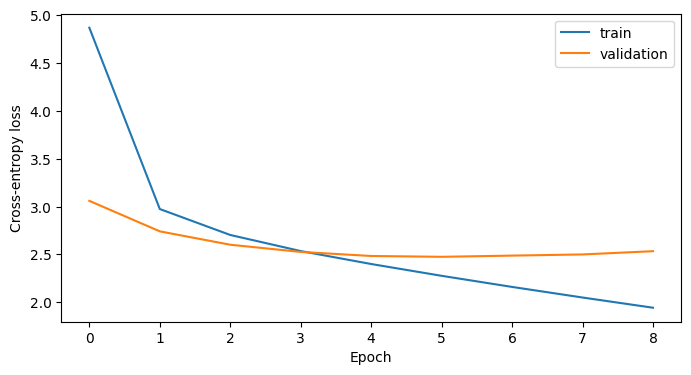

In [8]:
# ============================================
# Step 1: Import tqdm for displaying training progress
# ============================================
from tqdm.auto import tqdm


# ============================================
# Step 2: Define the optimizer
#
# AdamW is used to update the model parameters.
# Weight decay helps reduce overfitting.
# ============================================
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01
)


# ============================================
# Step 3: Define the learning rate scheduler
#
# CosineAnnealingLR gradually decreases the
# learning rate following a cosine schedule.
# ============================================
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)


# ============================================
# Step 4: Define the loss function
#
# CrossEntropyLoss compares the predicted token
# distribution with the target caption tokens.
#
# PAD tokens are ignored because they do not
# represent actual words.
# ============================================
criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID
)


# ============================================
# Step 5: Initialize the GradScaler
#
# GradScaler is used for mixed-precision training
# to improve GPU memory usage and training speed.
#
# It is enabled only when CUDA is available.
# ============================================
scaler = torch.amp.GradScaler(
    'cuda',
    enabled=(DEVICE.type == 'cuda')
)


# ============================================
# Step 6: Define one complete training/validation epoch
#
# The same function is used for both:
# - Training
# - Validation
# ============================================
def run_epoch(
    loader,
    training=True,
    epoch=1
):

    # ============================================
    # Step 6.1: Set the model mode
    #
    # Training mode enables layers such as Dropout
    # and BatchNorm training behavior.
    #
    # Evaluation mode disables training-specific behavior.
    # ============================================
    model.train(training)


    # ============================================
    # Step 6.2: Initialize loss and token counters
    #
    # total_loss accumulates the loss over all
    # non-padding tokens.
    #
    # token_count keeps track of the number of
    # valid target tokens.
    # ============================================
    total_loss = 0.0
    token_count = 0


    # ============================================
    # Step 6.3: Enable gradients only during training
    #
    # During validation, gradients are disabled to
    # reduce memory usage and computation.
    # ============================================
    context = (
        torch.enable_grad()
        if training
        else torch.no_grad()
    )


    # ============================================
    # Step 6.4: Iterate over the DataLoader
    # ============================================
    with context:

        for images, captions_batch in tqdm(
            loader,
            desc=(
                f"Epoch {epoch:02d}/{EPOCHS} | "
                f"{'Train' if training else 'Valid'}"
            ),
            dynamic_ncols=True
        ):

            # ============================================
            # Step 6.5: Move images and captions to
            # the selected device.
            #
            # non_blocking=True can speed up CPU-to-GPU
            # transfers when pinned memory is available.
            # ============================================
            images = images.to(
                DEVICE,
                non_blocking=True
            )

            captions_batch = captions_batch.to(
                DEVICE,
                non_blocking=True
            )


            # ============================================
            # Step 6.6: Prepare decoder inputs and targets
            #
            # Example:
            #
            # Caption:
            # <bos> a dog runs <eos>
            #
            # Decoder input:
            # <bos> a dog runs
            #
            # Target:
            # a dog runs <eos>
            #
            # This trains the model to predict the next token.
            # ============================================
            decoder_input = captions_batch[:, :-1]
            targets = captions_batch[:, 1:]


            # ============================================
            # Step 6.7: Clear the previous gradients
            #
            # set_to_none=True is more memory-efficient
            # than setting gradients to zero.
            # ============================================
            if training:
                optimizer.zero_grad(
                    set_to_none=True
                )


            # ============================================
            # Step 6.8: Enable mixed-precision computation
            #
            # On CUDA devices, some operations use lower
            # precision to improve speed and reduce memory usage.
            # ============================================
            with torch.amp.autocast(
                device_type=DEVICE.type,
                enabled=(DEVICE.type == 'cuda')
            ):

                # ============================================
                # Step 6.9: Forward pass
                #
                # Image + previous caption tokens
                #        ↓
                #      Model
                #        ↓
                # Predicted vocabulary logits
                # ============================================
                logits = model(
                    images,
                    decoder_input
                )


                # ============================================
                # Step 6.10: Calculate the Cross-Entropy loss
                #
                # Flatten predictions and targets so that
                # CrossEntropyLoss can process every token.
                # ============================================
                loss = criterion(
                    logits.reshape(
                        -1,
                        logits.size(-1)
                    ),
                    targets.reshape(-1)
                )


            # ============================================
            # Step 6.11: Perform the backward pass
            # only during training.
            # ============================================
            if training:

                # Scale the loss before backpropagation
                # for numerical stability in mixed precision.
                scaler.scale(loss).backward()


                # ============================================
                # Step 6.12: Unscale gradients before
                # applying gradient clipping.
                # ============================================
                scaler.unscale_(
                    optimizer
                )


                # ============================================
                # Step 6.13: Clip gradients
                #
                # This prevents extremely large gradients
                # from destabilizing the training process.
                # ============================================
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    1.0
                )


                # ============================================
                # Step 6.14: Update model parameters
                # using the scaled gradients.
                # ============================================
                scaler.step(
                    optimizer
                )


                # ============================================
                # Step 6.15: Update the GradScaler
                # for the next training iteration.
                # ============================================
                scaler.update()


            # ============================================
            # Step 6.16: Count valid target tokens
            #
            # Padding tokens are excluded because they
            # do not represent actual caption words.
            # ============================================
            count = targets.ne(
                PAD_ID
            ).sum().item()


            # ============================================
            # Step 6.17: Accumulate the weighted loss
            #
            # Multiplying by the number of valid tokens
            # allows us to calculate the average loss
            # correctly across the entire epoch.
            # ============================================
            total_loss += (
                loss.item() * count
            )

            token_count += count


    # ============================================
    # Step 6.18: Return the average token-level loss
    # ============================================
    return total_loss / max(
        token_count,
        1
    )


# ============================================
# Step 7: Initialize training history
#
# These lists will store the training and validation
# loss after every epoch.
# ============================================
history = {
    'train_loss': [],
    'validation_loss': []
}


# ============================================
# Step 8: Initialize early stopping variables
#
# best_loss stores the best validation loss observed.
#
# epochs_without_improvement counts consecutive epochs
# where the validation loss does not improve.
# ============================================
best_loss = float('inf')
epochs_without_improvement = 0


# ============================================
# Step 9: Start the training loop
# ============================================
for epoch in range(
    1,
    EPOCHS + 1
):

    # ============================================
    # Step 9.1: Run one training epoch
    # and one validation epoch.
    # ============================================
    train_loss = run_epoch(
        train_loader,
        True,
        epoch
    )

    validation_loss = run_epoch(
        validation_loader,
        False,
        epoch
    )


    # ============================================
    # Step 9.2: Update the learning rate
    # after completing the epoch.
    # ============================================
    scheduler.step()


    # ============================================
    # Step 9.3: Store the current losses
    # in the training history.
    # ============================================
    history['train_loss'].append(
        train_loss
    )

    history['validation_loss'].append(
        validation_loss
    )


    # ============================================
    # Step 9.4: Display the current epoch results
    # ============================================
    print(
        f'\nEpoch {epoch:02d}/{EPOCHS} | '
        f'train CE: {train_loss:.4f} | '
        f'valid CE: {validation_loss:.4f}'
    )


    # ============================================
    # Step 9.5: Check whether validation loss improved
    # ============================================
    if validation_loss < best_loss:

        # ============================================
        # Step 9.6: Update the best validation loss
        # ============================================
        best_loss = validation_loss
        epochs_without_improvement = 0


        # ============================================
        # Step 9.7: Save the best model checkpoint
        #
        # The checkpoint contains:
        # - Model weights
        # - Vocabulary mapping
        # - Reverse vocabulary mapping
        # - Maximum caption length
        # ============================================
        torch.save(
            {
                'model_state': model.state_dict(),
                'stoi': stoi,
                'itos': itos,
                'max_length': MAX_LENGTH
            },
            '/kaggle/working/best_scratch_captioner.pt'
        )

        print('Best checkpoint saved.')


    else:

        # ============================================
        # Step 9.8: Increase the early stopping counter
        # because validation loss did not improve.
        # ============================================
        epochs_without_improvement += 1


        # ============================================
        # Step 9.9: Stop training if validation loss
        # has not improved for PATIENCE consecutive epochs.
        # ============================================
        if epochs_without_improvement >= PATIENCE:

            print(
                f'Early stopping after '
                f'{PATIENCE} epochs without improvement.'
            )

            break


# ============================================
# Step 10: Plot training and validation loss
#
# This helps visualize:
# - Whether the model is learning
# - Whether validation loss improves
# - Possible overfitting
# ============================================
plt.figure(
    figsize=(8, 4)
)

plt.plot(
    history['train_loss'],
    label='train'
)

plt.plot(
    history['validation_loss'],
    label='validation'
)

plt.xlabel(
    'Epoch'
)

plt.ylabel(
    'Cross-entropy loss'
)

plt.legend()

plt.show()

Caption evaluation:   0%|          | 0/500 [00:00<?, ?it/s]

BLEU-4 : 0.2032
METEOR : 0.3950
CIDEr  : 0.6556
Independent test images evaluated: 500


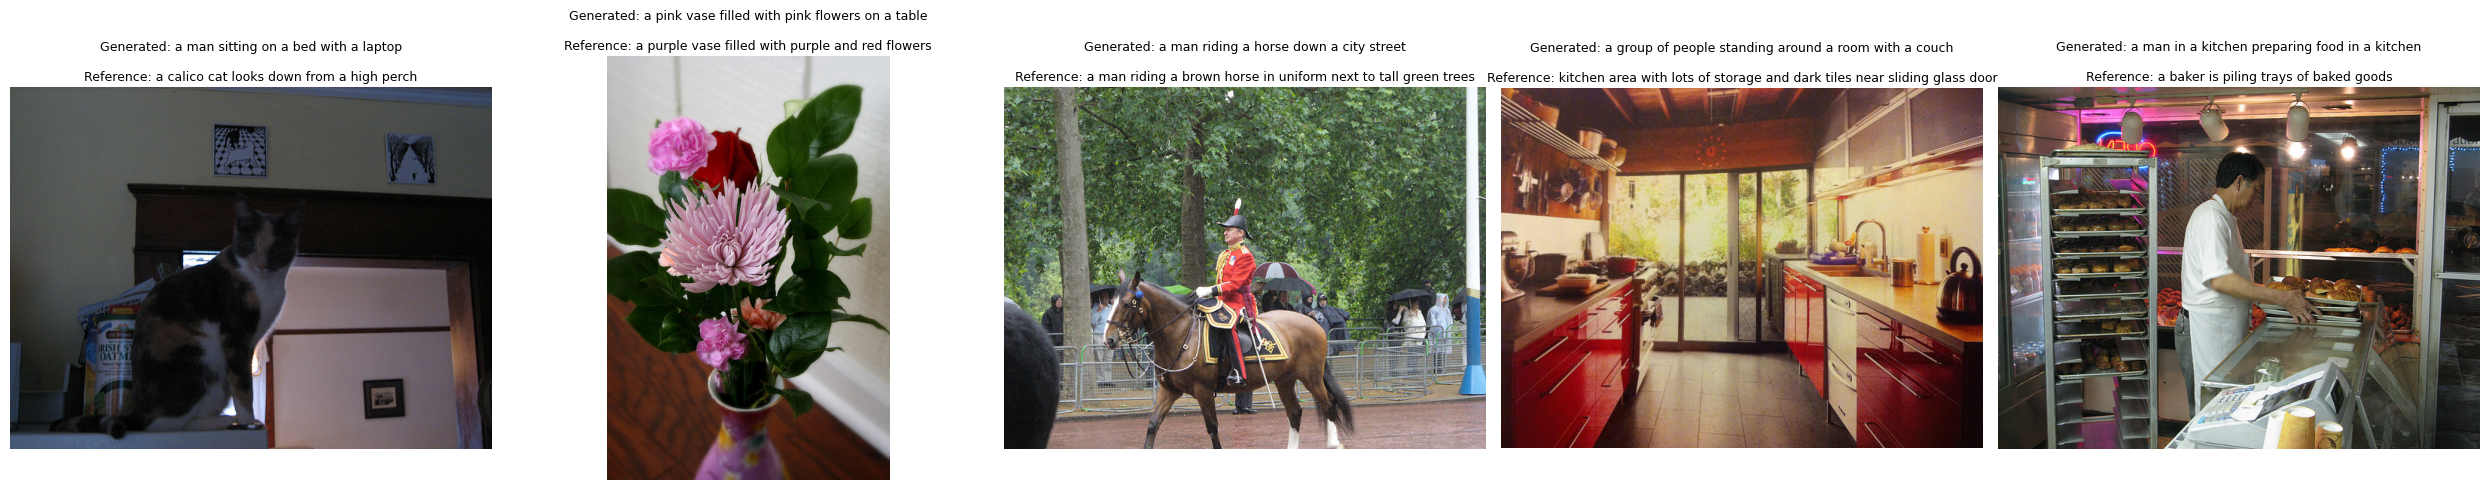

Saved best checkpoint: /kaggle/working/best_scratch_captioner.pt


In [9]:
# ============================================
# Step 1: Import libraries required for evaluation
# ============================================
import importlib.util
import subprocess
import sys


# ============================================
# Step 2: Download the NLTK resources required
# for METEOR evaluation.
#
# WordNet is used for stemming and synonym matching.
# The resources are downloaded only if they are missing.
# ============================================
import nltk

for resource in ('wordnet', 'omw-1.4'):

    try:
        nltk.data.find(
            f'corpora/{resource}'
        )

    except LookupError:
        nltk.download(
            resource,
            quiet=True
        )


# ============================================
# Step 3: Import the METEOR evaluation function
# ============================================
from nltk.translate.meteor_score import meteor_score


# ============================================
# Step 4: Install pycocoevalcap if it is not
# already available.
#
# pycocoevalcap provides the standard CIDEr
# implementation used for image captioning evaluation.
# ============================================
if importlib.util.find_spec(
    'pycocoevalcap'
) is None:

    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        '-q',
        'pycocoevalcap'
    ])


# ============================================
# Step 5: Import the CIDEr evaluator
# ============================================
from pycocoevalcap.cider.cider import Cider


# ============================================
# Step 6: Load the best model checkpoint
#
# The checkpoint contains the model weights,
# vocabulary mappings, and maximum caption length.
# ============================================
checkpoint = torch.load(
    '/kaggle/working/best_scratch_captioner.pt',
    map_location=DEVICE
)


# ============================================
# Step 7: Restore the best model weights
# and switch the model to evaluation mode.
# ============================================
model.load_state_dict(
    checkpoint['model_state']
)

model.eval()


# ============================================
# Step 8: Define the caption generation function
#
# The model generates one token at a time:
#
# <bos>
#   ↓
# word 1
#   ↓
# word 2
#   ↓
# ...
#   ↓
# <eos>
#
# Greedy decoding is used by selecting the token
# with the highest probability at every step.
# ============================================
@torch.no_grad()
def generate_caption(
    image_tensor,
    temperature=1.0
):

    # ============================================
    # Step 8.1: Add the batch dimension and move
    # the image to the selected device.
    # ============================================
    image_tensor = image_tensor.unsqueeze(
        0
    ).to(DEVICE)


    # ============================================
    # Step 8.2: Start the generated sequence
    # with the Beginning-of-Sentence token.
    # ============================================
    generated = [BOS_ID]


    # ============================================
    # Step 8.3: Generate tokens one by one
    # until EOS is produced or MAX_LENGTH is reached.
    # ============================================
    for _ in range(MAX_LENGTH - 1):

        # ============================================
        # Step 8.4: Convert the generated token IDs
        # into a tensor that can be passed to the model.
        # ============================================
        input_ids = torch.tensor(
            [generated],
            device=DEVICE
        )


        # ============================================
        # Step 8.5: Run the model and obtain the
        # predictions for the next token.
        #
        # Only the prediction at the last sequence
        # position is needed.
        # ============================================
        next_token = int(
            torch.argmax(
                model(
                    image_tensor,
                    input_ids
                )[:, -1] / temperature,
                dim=-1
            ).item()
        )


        # ============================================
        # Step 8.6: Stop generation when the
        # End-of-Sentence token is predicted.
        # ============================================
        if next_token == EOS_ID:
            break


        # ============================================
        # Step 8.7: Add the predicted token
        # to the generated sequence.
        # ============================================
        generated.append(
            next_token
        )


    # ============================================
    # Step 8.8: Convert token IDs back into words
    # and remove the initial BOS token.
    # ============================================
    return ' '.join(
        itos[token]
        for token in generated[1:]
    )


# ============================================
# Step 9: Define a helper function for generating
# n-grams from a token sequence.
#
# Example:
# tokens = ["a", "dog", "runs"]
#
# bigrams:
# ("a", "dog")
# ("dog", "runs")
# ============================================
def ngrams(
    tokens,
    n
):
    return Counter(
        tuple(
            tokens[i:i + n]
        )
        for i in range(
            len(tokens) - n + 1
        )
    )


# ============================================
# Step 10: Define a custom corpus-level BLEU function
#
# This implementation calculates BLEU up to 4-grams
# and applies brevity penalty.
# ============================================
def corpus_bleu(
    predictions,
    references,
    max_n=4
):

    # ============================================
    # Step 10.1: Initialize counters for clipped
    # n-gram matches and total predicted n-grams.
    # ============================================
    clipped = [0] * max_n
    totals = [0] * max_n


    # ============================================
    # Step 10.2: Initialize total prediction and
    # reference lengths for the brevity penalty.
    # ============================================
    pred_length = 0
    ref_length = 0


    # ============================================
    # Step 10.3: Process every prediction together
    # with its reference captions.
    # ============================================
    for prediction, refs in zip(
        predictions,
        references
    ):

        # ============================================
        # Step 10.4: Tokenize the generated caption
        # and all reference captions.
        # ============================================
        pred_tokens = prediction.split()
        ref_tokens = [
            ref.split()
            for ref in refs
        ]


        # ============================================
        # Step 10.5: Update prediction length and
        # choose the reference length closest to it.
        # ============================================
        pred_length += len(
            pred_tokens
        )

        ref_length += min(
            (
                len(ref)
                for ref in ref_tokens
            ),
            key=lambda length:
                abs(
                    length
                    - len(pred_tokens)
                )
        )


        # ============================================
        # Step 10.6: Calculate clipped n-gram matches
        # for 1-grams through 4-grams.
        # ============================================
        for n in range(
            1,
            max_n + 1
        ):

            # Count n-grams in the prediction.
            counts = ngrams(
                pred_tokens,
                n
            )

            # Count the total predicted n-grams.
            totals[n - 1] += sum(
                counts.values()
            )


            # ============================================
            # Step 10.7: Find the maximum reference count
            # for every n-gram.
            # ============================================
            max_ref_counts = Counter()

            for ref in ref_tokens:

                for gram, count in ngrams(
                    ref,
                    n
                ).items():

                    max_ref_counts[gram] = max(
                        max_ref_counts[gram],
                        count
                    )


            # ============================================
            # Step 10.8: Calculate clipped matches.
            # ============================================
            clipped[n - 1] += sum(
                min(
                    count,
                    max_ref_counts[gram]
                )
                for gram, count in counts.items()
            )


    # ============================================
    # Step 10.9: Calculate smoothed n-gram precisions.
    #
    # Adding 1 prevents zero precision when an n-gram
    # has no matching reference.
    # ============================================
    precisions = [
        (clipped[i] + 1)
        / (totals[i] + 1)
        for i in range(max_n)
    ]


    # ============================================
    # Step 10.10: Calculate BLEU brevity penalty
    # and combine it with the geometric mean of
    # the n-gram precisions.
    # ============================================
    return (
        min(
            1.0,
            math.exp(
                1
                - ref_length
                / max(pred_length, 1)
            )
        )
        * math.exp(
            sum(
                math.log(p)
                for p in precisions
            ) / max_n
        )
    )


# ============================================
# Step 11: Group all test references by image
#
# An image may have multiple reference captions.
# We keep all of them for evaluation.
# ============================================
references_by_image = (
    test_table
    .groupby('image_name')
    .caption
    .apply(list)
)


# ============================================
# Step 12: Keep only one row per test image
#
# This creates the list of unique images that
# will be evaluated.
# ============================================
evaluation_rows = (
    test_table
    .drop_duplicates('image_name')
    .set_index('image_name')
    .loc[
        sorted(
            references_by_image.index
        )
    ]
)


# ============================================
# Step 13: Generate one caption for every
# independent test image.
#
# The test images have never been used during training.
# ============================================
predictions = [
    generate_caption(
        image_transform(
            Image.open(
                row.image_path
            ).convert('RGB')
        )
    )
    for _, row in tqdm(
        evaluation_rows.iterrows(),
        total=len(evaluation_rows),
        desc='Caption evaluation'
    )
]


# ============================================
# Step 14: Collect all reference captions
# corresponding to each test image.
# ============================================
references = [
    references_by_image[name]
    for name in evaluation_rows.index
]


# ============================================
# Step 15: Calculate BLEU-4
#
# BLEU measures n-gram overlap between
# generated captions and reference captions.
#
# BLEU-4 considers 1-gram through 4-gram matches.
# ============================================
bleu4 = corpus_bleu(
    predictions,
    references
)


# ============================================
# Step 16: Calculate METEOR
#
# METEOR considers word-level matches and can
# account for stemming and synonyms through WordNet.
# ============================================
meteor = float(
    np.mean([
        meteor_score(
            [
                reference.split()
                for reference in refs
            ],
            prediction.split()
        )
        for prediction, refs in zip(
            predictions,
            references
        )
    ])
)


# ============================================
# Step 17: Prepare predictions and references
# in the format expected by pycocoevalcap.
# ============================================
gts = {
    str(index): refs
    for index, refs in enumerate(references)
}

res = {
    str(index): [prediction]
    for index, prediction in enumerate(predictions)
}


# ============================================
# Step 18: Calculate the CIDEr score
#
# CIDEr measures how similar the generated caption
# is to the reference captions using TF-IDF weighted
# n-gram similarity.
# ============================================
cider, _ = Cider().compute_score(
    gts,
    res
)


# ============================================
# Step 19: Display the final evaluation metrics
# ============================================
print(
    f'BLEU-4 : {bleu4:.4f}'
)

print(
    f'METEOR : {meteor:.4f}'
)

print(
    f'CIDEr  : {cider:.4f}'
)

print(
    f'Independent test images evaluated: '
    f'{len(evaluation_rows):,}'
)


# ============================================
# Step 20: Select a small random sample of
# test images for qualitative evaluation.
# ============================================
shown = evaluation_rows.sample(
    min(5, len(evaluation_rows)),
    random_state=SEED
)


# ============================================
# Step 21: Create a visualization of generated
# captions versus reference captions.
# ============================================
fig, axes = plt.subplots(
    1,
    len(shown),
    figsize=(5 * len(shown), 5)
)

axes = np.atleast_1d(
    axes
)


# ============================================
# Step 22: Display each test image together
# with its generated and reference captions.
# ============================================
for axis, (name, row) in zip(
    axes,
    shown.iterrows()
):

    # Load the image for visualization.
    image = Image.open(
        row.image_path
    ).convert('RGB')


    # Find the generated caption corresponding
    # to the current image.
    prediction = predictions[
        list(evaluation_rows.index).index(name)
    ]


    # Display the image and caption comparison.
    axis.imshow(image)

    axis.set_title(
        f'Generated: {prediction}\n\n'
        f'Reference: {references_by_image[name][0]}',
        fontsize=9,
        wrap=True
    )

    axis.axis('off')


# ============================================
# Step 23: Adjust the layout and display the figure
# ============================================
plt.tight_layout()
plt.show()


# ============================================
# Step 24: Confirm the location of the saved
# best model checkpoint.
# ============================================
print(
    'Saved best checkpoint: '
    '/kaggle/working/best_scratch_captioner.pt'
)